In [207]:
import json
import numpy as np
import os
from eval_utils import load_setup, calculator, extract_deal

In [208]:
game = 'base_rewritten'

# Change accordingly
OUTPUT_DIR =f'/Users/joshuarosenthal/Masters/FACT/FACT29/our_games_descriptions/base/output/our_outputs/base_Qwen2.5-72B-Instruct-GPTQ-Int4'
AGENTS_NUM = 6
ISSUES_NUM = 5

In [209]:
agents, role_to_agents, incentive_to_agents = load_setup(OUTPUT_DIR,AGENTS_NUM,ISSUES_NUM)
answers_files = [ os.path.join(OUTPUT_DIR,filename) for filename in os.listdir(OUTPUT_DIR) if filename.startswith("history")]

In [ ]:
print(agents)

In [210]:
# DEV: Visualize the loaded data

print("Agents: \n", agents)
print("\n =======================\n")
print("Role to agents: \n", role_to_agents)
print("\n =======================\n")
print("Incentive to agents: \n", incentive_to_agents)
print("\n =======================\n")
print("Answers files: \n", answers_files)
print("\n =======================\n")

Agents: 
 {'Mayor': {'file_name': 'mayor', 'role': 'player', 'incentive': 'cooperative', 'scores': {'A': [14, 8, 0], 'B': [12, 8, 0], 'C': [24, 18, 12, 0], 'D': [40, 30, 23, 0], 'E': [0, 2, 4, 7, 10], 'min': 30}}, 'Other cities': {'file_name': 'other_cities', 'role': 'player', 'incentive': 'cooperative', 'scores': {'A': [0, 4, 10], 'B': [0, 0, 0], 'C': [12, 8, 6, 0], 'D': [0, 8, 13, 18], 'E': [60, 45, 30, 15, 0], 'min': 31}}, 'Local Labour Union': {'file_name': 'union', 'role': 'player', 'incentive': 'cooperative', 'scores': {'A': [15, 20, 0], 'B': [0, 0, 0], 'C': [42, 35, 25, 0], 'D': [30, 20, 10, 0], 'E': [2, 4, 6, 8, 0], 'min': 50}}, 'SportCo': {'file_name': 'SportCo', 'role': 'p1', 'incentive': 'cooperative', 'scores': {'A': [14, 8, 0], 'B': [11, 7, 0], 'C': [0, 5, 10, 17], 'D': [35, 29, 20, 0], 'E': [0, 5, 10, 15, 23], 'min': 55}}, 'Department of Tourism': {'file_name': 'DoT', 'role': 'p2', 'incentive': 'cooperative', 'scores': {'A': [0, 11, 5], 'B': [0, 20, 25], 'C': [0, 2, 4, 9]

In [211]:
def get_score(agent_name, deal): # I know this is kinda dumb, i just wanted to keep the notation
    return calculator(agents[agent_name]['scores'], deal, ISSUES_NUM)

In [212]:
def is_valid(deal, agents):
    """
    Check if a deal is valid.
    A deal is valid if:
    - It is acceptable for all players (over their thresholds).
    - Both Player 1 (p1) and Player 2 (p2) must also accept the deal.
    """
    # Check for all agents if the deal meets their thresholds
    for agent_name, agent_data in agents.items():
        scores = agent_data['scores']
        threshold = scores['min']  # The threshold for this agent
        deal_score = calculator(scores, deal)
        
        if deal_score < threshold:
            return False  # Deal not acceptable for this agent

    for role in ['p1', 'p2']:
        agent_name = role_to_agents[role]
        scores = agents[agent_name]['scores']
        threshold = scores['min']
        deal_score = calculator(scores, deal)
        
        if deal_score < threshold:
            return False  # Deal not acceptable for Player 1 or Player 2

    return True


In [213]:
def compute_usw(deal, agents):

    # FIRST IMPLEMENTATION:
    # This checks whether the deal is valid and returns the sum of the scores of all agents
    # Which does not provide intuitive results since many deals are not valid and we want to see a progression
    # For the sake of visulization I will obtain usw as the sum of the scores of all agents no matter the validity of the deal

    # Compute the utilitarian social welfare for a deal
    # if is_valid(deal, agents):
    #     print(f"Deal {deal} is valid")  
    #     return sum([get_score(agent_name, deal) for agent_name in agents])
    # else:
    #     # Sum of thresholds
    #     return sum([agents[agent_name]['scores']['min'] for agent_name in agents])

    # SECOND IMPLEMENTATION:
    # This implementation returns the sum of the scores of all agents for a valid deal
    return sum([get_score(agent_name, deal) for agent_name in agents])


In [ ]:
print

In [214]:
from itertools import product
def compute_optimal_usw(agents):
    # Extract all issues and their ranges, excluding 'min'
    first_agent_scores = next(iter(agents.values()))['scores']
    issues = [issue for issue in first_agent_scores.keys() if issue != 'min']
    num_options_per_issue = {issue: len(first_agent_scores[issue]) for issue in issues}

    # Generate all possible deals (Cartesian product of sub-issues)
    all_deals = product(*[[(issue, i + 1) for i in range(num_options_per_issue[issue])] for issue in issues])

    # Initialize variables to track the optimal deal and its USW
    optimal_deal = None
    highest_usw = float('-inf')

    # Loop through all possible deals
    for deal in all_deals:
        # Compute the utilitarian social welfare for the current deal
        usw = compute_usw(deal, agents)

        # Update the optimal deal if this deal has a higher USW
        if usw > highest_usw:
            highest_usw = usw
            optimal_deal = deal

    # Return the deal with the highest USW
    return optimal_deal, highest_usw
    
optimal_esw_deal, highest_usw = compute_optimal_usw(agents)


In [215]:
def compute_minimal_usw(agents):
    # Function to compute the lowest scoring deal (in terms of usw) that is still valid
    # Extract all issues and their ranges, excluding 'min'
    first_agent_scores = next(iter(agents.values()))['scores']
    issues = [issue for issue in first_agent_scores.keys() if issue != 'min']
    num_options_per_issue = {issue: len(first_agent_scores[issue]) for issue in issues}

    # Generate all possible deals (Cartesian product of sub-issues)
    all_deals = product(*[[(issue, i + 1) for i in range(num_options_per_issue[issue])] for issue in issues])

    # Initialize variables to track the optimal deal and its USW
    minimal_deal = None
    lowest_usw = float('inf')

    # Loop through all possible deals
    for deal in all_deals:
        # Compute the utilitarian social welfare for the current deal
        usw = compute_usw(deal, agents)

        # Update the optimal deal if this deal has a higher USW
        if usw < lowest_usw and is_valid(deal, agents):
            lowest_usw = usw
            minimal_deal = deal

    # Return the deal with the highest USW
    return minimal_deal, lowest_usw

minimal__esw_deal, lowest_usw = compute_minimal_usw(agents)

In [216]:
def compute_esw(deal, agents):
    """
    Compute the egalitarian social welfare (ESW) for a given deal.
    ESW is the minimum utility achieved by any agent for the deal.

    Parameters:
    - deal: The deal being evaluated (list of tuples representing sub-issues).
    - agents: A dictionary of agents with their scores and thresholds.

    Returns:
    - Egalitarian social welfare (minimum utility among all agents).
    """
    # Initialize ESW to a large positive value
    esw = float('inf')

    # Compute utility for each agent and update ESW
    for agent_name, _ in agents.items():
        agent_utility = get_score(agent_name, deal)
        esw = min(esw, agent_utility)  # Update ESW with the minimum utility

    return esw

In [217]:
from itertools import product

def compute_optimal_esw(agents):
    """
    Compute the optimal egalitarian social welfare (ESW) and the corresponding deal.

    Parameters:
    - agents: A dictionary of agents with their scores and thresholds.

    Returns:
    - optimal_deal: The deal with the highest egalitarian social welfare.
    - highest_esw: The value of the highest ESW.
    """
    # Extract all issues and their ranges, excluding 'min'
    first_agent_scores = next(iter(agents.values()))['scores']
    issues = [issue for issue in first_agent_scores.keys() if issue != 'min']
    num_options_per_issue = {issue: len(first_agent_scores[issue]) for issue in issues}

    # Generate all possible deals (Cartesian product of sub-issues)
    all_deals = product(*[[(issue, i + 1) for i in range(num_options_per_issue[issue])] for issue in issues])

    # Initialize variables to track the optimal deal and its ESW
    optimal_deal = None
    highest_esw = float('-inf')

    # Loop through all possible deals
    for deal in all_deals:
        # Compute the egalitarian social welfare for the current deal
        esw = compute_esw(deal, agents)

        # Update the optimal deal if this deal has a higher ESW
        if esw > highest_esw:
            highest_esw = esw
            optimal_deal = deal

    # Return the deal with the highest ESW
    return optimal_deal, highest_esw

optimal_esw_deal, highest_esw = compute_optimal_esw(agents)

In [218]:
def compute_nash(deal, agents, epsilon=0.001):
    """
    Compute the Nash Bargain Value (NBV) for a given deal.

    Parameters:
    - deal: The deal being evaluated (list of tuples representing sub-issues).
    - agents: A dictionary of agents with their scores and thresholds.

    Returns:
    - The Nash Bargain Value for the given deal. Returns 0 if any agent's utility is below their threshold.
    
    We compute the Weighted Nash Bargain Value (WNBV) for a deal.
    Adds a small penalty (epsilon) for utilities below thresholds.
    """

    wnbv = 1  # Initialize WNBV as 1 (product accumulator)
    
    for agent_name, agent_data in agents.items():
        scores = agent_data['scores']
        threshold = scores['min']
        utility = calculator(scores, deal)

        # Add epsilon for utilities below thresholds
        wnbv *= max(utility - threshold, epsilon)

    return wnbv

In [219]:
def compute_max_nash(agents):
    """
    Compute the deal with the maximum Nash Bargain Value (NBV).

    Parameters:
    - agents: A dictionary of agents with their scores and thresholds.

    Returns:
    - optimal_deal: The deal with the highest Nash Bargain Value.
    - max_nbv: The maximum Nash Bargain Value.
    """
    # Extract all issues and their ranges, excluding 'min'
    first_agent_scores = next(iter(agents.values()))['scores']
    issues = [issue for issue in first_agent_scores.keys() if issue != 'min']
    num_options_per_issue = {issue: len(first_agent_scores[issue]) for issue in issues}

    # Generate all possible deals (Cartesian product of sub-issues)
    all_deals = product(*[[(issue, i + 1) for i in range(num_options_per_issue[issue])] for issue in issues])

    # Initialize variables to track the optimal deal and its NBV
    optimal_deal = None
    max_nbv = float('-inf')

    # Loop through all possible deals
    for deal in all_deals:
        # Compute the Nash Bargain Value for the current deal
        nbv = compute_nash(deal, agents)

        # Update the optimal deal if this deal has a higher NBV
        if nbv > max_nbv:
            max_nbv = nbv
            optimal_deal = deal

    # Return the deal with the highest NBV
    return optimal_deal, max_nbv

optimal_nash_deal, max_nash = compute_max_nash(agents)

In [220]:
def compute_distance(deal1, deal2, method='usw', norm='l1'):
    # Compute the distance between two deals
    if method == 'usw':
        usw1 = compute_usw(deal1, agents)
        usw2 = compute_usw(deal2, agents)
        if norm == 'l1':
            return np.abs(usw1 - usw2)
        elif norm == 'l2':
            return np.linalg.norm(usw1 - usw2)
    elif method == 'nash':
        # TODO: Implement Nash distance
        return Exception("Nash distance not implemented yet")
    elif method == 'esw':
        if norm == 'l1':
            #d(deal_i, deal_j) = |min_p S_p(deal_i) - min_p S_p(deal_j)|
            return np.abs(compute_esw(deal1, agents) - compute_esw(deal2, agents))
        elif norm == 'l2':
            return np.linalg.norm(compute_esw(deal1, agents) - compute_esw(deal2, agents))
    else:
        return Exception("Invalid method")

In [221]:
# Loop through all the games 

for file_ in answers_files[:1]:
    answers = json.load(open(file_))

    metrics = {
        'usw': [],
        'esw': [],
        'nash': []
    }

    # Extract all the deals
    deals = []
    for i, round_ in enumerate(answers['rounds']):
        name,answer = round_['agent'], round_['public_answer']
        deal = extract_deal(answer, AGENTS_NUM)[0][:-1] # Fixing their format, this is probably a temporary fix
        # print("Deal: \n", deal)
        deals.append(deal)


        # METRICS COMPUTATIONS

        # Utilitarian Social Welfare (USW)
        usw = compute_usw(deal, agents)
        metrics['usw'].append(usw)
        #print(f"Round {i + 1} - {name} - USW: {usw}")

        # Egalitarian Social Welfare (ESW)
        esw = compute_esw(deal, agents)
        metrics['esw'].append(esw)
        #print(f"Round {i + 1} - {name} - ESW: {esw}")

        # Nash bargaining solution
        nash = compute_nash(deal, agents)
        metrics['nash'].append(nash)
        print(f"Round {i + 1} - {name} - Nash: {nash}")


        
        
        
    # DEV: Visualize the extracted deals
    # print("Deals: \n", (deals))
    # print("\n =======================\n")

    

Round 1 - SportCo - Nash: 2.0699999999999997e-09
Round 2 - Local Labour Union - Nash: 0.21648000000000003
Round 3 - SportCo - Nash: 0.21648000000000003
Round 4 - Environmental League - Nash: 0.51408
Round 5 - Department of Tourism - Nash: 0.35935200000000006
Round 6 - Mayor - Nash: 0.21648000000000003
Round 7 - Other cities - Nash: 0.35935200000000006
Round 8 - Local Labour Union - Nash: 0.21648000000000003
Round 9 - Other cities - Nash: 0.35935200000000006
Round 10 - SportCo - Nash: 0.21648000000000003
Round 11 - Environmental League - Nash: 2960.0999999999995
Round 12 - Department of Tourism - Nash: 0.35935200000000006
Round 13 - Mayor - Nash: 0.21648000000000003
Round 14 - Environmental League - Nash: 2960.0999999999995
Round 15 - Other cities - Nash: 2.0020000000000005e-06
Round 16 - Department of Tourism - Nash: 0.35935200000000006
Round 17 - Local Labour Union - Nash: 805.7520000000001
Round 18 - SportCo - Nash: 0.21648000000000003
Round 19 - Mayor - Nash: 0.21648000000000003
Rou

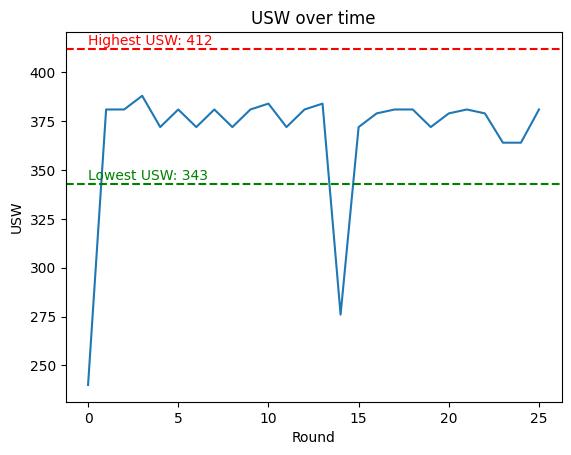

In [222]:
# Plot the USW over time
import matplotlib.pyplot as plt

plt.plot(metrics['usw'])
plt.xlabel('Round')
plt.text(0, highest_usw+2, f'Highest USW: {highest_usw}', color='r')
plt.axhline(y=highest_usw, color='r', linestyle='--')
plt.text(0, lowest_usw+2, f'Lowest USW: {lowest_usw}', color='g')
plt.axhline(y=lowest_usw, color='g', linestyle='--')
plt.ylabel('USW')
plt.title('USW over time')
plt.show()

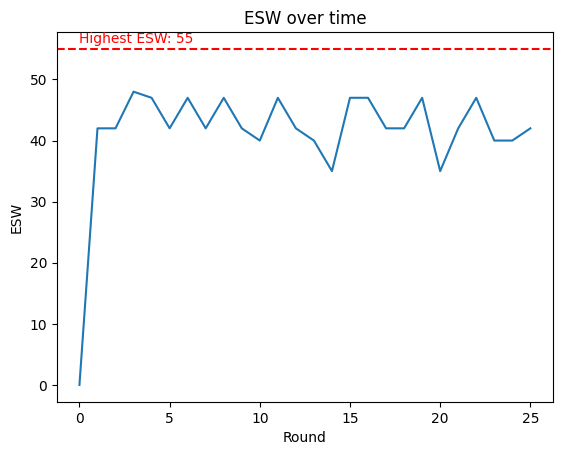

In [223]:
# Plot the ESW over time
plt.plot(metrics['esw'])
plt.xlabel('Round')
plt.text(0, highest_esw+1, f'Highest ESW: {highest_esw}', color='r')
plt.axhline(y=highest_esw, color='r', linestyle='--')
plt.ylabel('ESW')
plt.title('ESW over time')
plt.show()

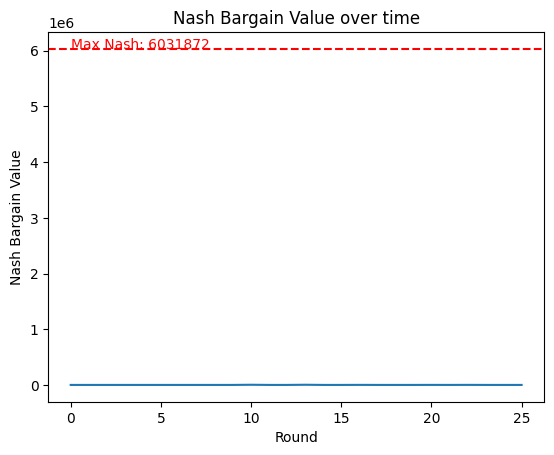

In [224]:
# Plot the Nash Bargain Value over time
plt.plot(metrics['nash'])
plt.xlabel('Round')
plt.text(0, max_nash+1, f'Max Nash: {max_nash}', color='r')
plt.axhline(y=max_nash, color='r', linestyle='--')
plt.ylabel('Nash Bargain Value')
plt.title('Nash Bargain Value over time')
plt.show()

File 1/20, Round 2 - Local Labour Union - Nash: 0.21648000000000003
File 1/20, Round 3 - SportCo - Nash: 0.21648000000000003
File 1/20, Round 4 - Environmental League - Nash: 0.51408
File 1/20, Round 5 - Department of Tourism - Nash: 0.35935200000000006
File 1/20, Round 6 - Mayor - Nash: 0.21648000000000003
File 1/20, Round 7 - Other cities - Nash: 0.35935200000000006
File 1/20, Round 8 - Local Labour Union - Nash: 0.21648000000000003
File 1/20, Round 9 - Other cities - Nash: 0.35935200000000006
File 1/20, Round 10 - SportCo - Nash: 0.21648000000000003
File 1/20, Round 11 - Environmental League - Nash: 2960.0999999999995
File 1/20, Round 12 - Department of Tourism - Nash: 0.35935200000000006
File 1/20, Round 13 - Mayor - Nash: 0.21648000000000003
File 1/20, Round 14 - Environmental League - Nash: 2960.0999999999995
File 1/20, Round 15 - Other cities - Nash: 2.0020000000000005e-06
File 1/20, Round 16 - Department of Tourism - Nash: 0.35935200000000006
File 1/20, Round 17 - Local Labour 

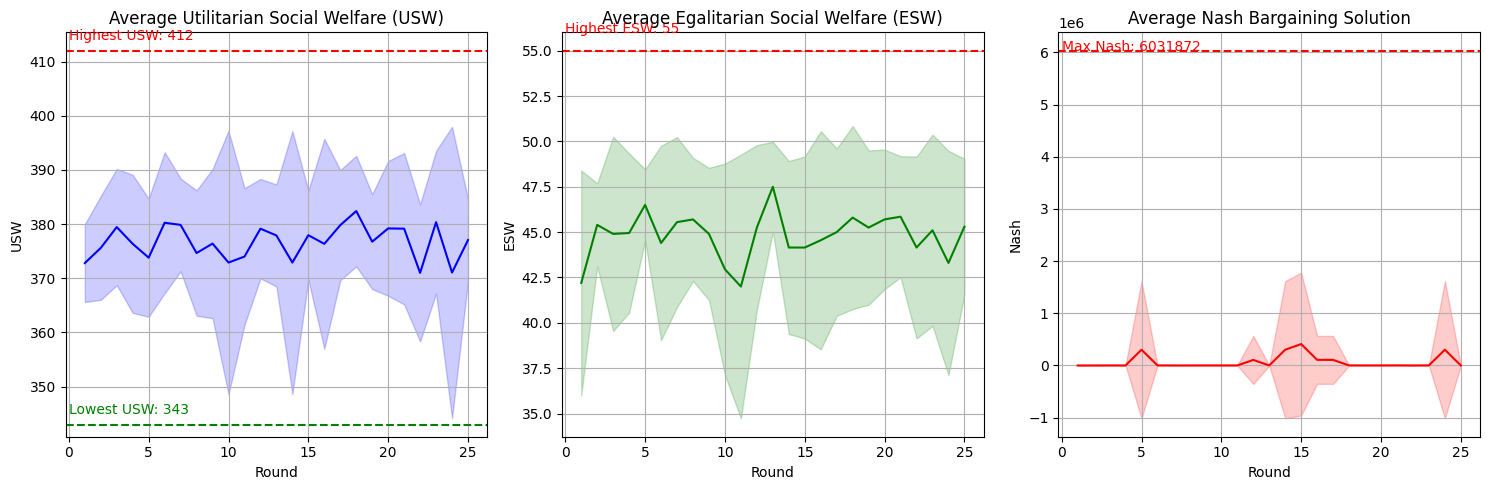

In [225]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Assuming these functions and variables are defined elsewhere
# from your_module import extract_deal, compute_usw, compute_esw, compute_nash, AGENTS_NUM, agents

# Initialize a data structure to hold metrics across all files
# Structure: metrics_aggregated['usw'][round_number] = [values from all files]
metrics_aggregated = defaultdict(lambda: defaultdict(list))

# Number of files to process
num_files = len(answers_files)

# Iterate over all files
for file_idx, file_ in enumerate(answers_files):
    with open(file_, 'r') as f:
        answers = json.load(f)
    
    # Temporary metrics for the current file
    metrics = {
        'usw': [],
        'esw': [],
        'nash': []
    }

    # Extract all the deals
    for round_idx, round_ in enumerate(answers['rounds']):
        if round_idx == 0:
            continue
        name, answer = round_['agent'], round_['public_answer']
        deal = extract_deal(answer, AGENTS_NUM)[0][:-1]  # Fixing their format, this is probably a temporary fix

        # METRICS COMPUTATIONS

        # Utilitarian Social Welfare (USW)
        usw = compute_usw(deal, agents)
        metrics['usw'].append(usw)

        # Egalitarian Social Welfare (ESW)
        esw = compute_esw(deal, agents)
        metrics['esw'].append(esw)

        # Nash bargaining solution
        nash = compute_nash(deal, agents)
        metrics['nash'].append(nash)

        print(f"File {file_idx + 1}/{num_files}, Round {round_idx + 1} - {name} - Nash: {nash}")

    # Aggregate metrics from the current file
    for metric_name, values in metrics.items():
        for round_idx, value in enumerate(values):
            metrics_aggregated[metric_name][round_idx].append(value)

# Now compute the average and standard deviation for each metric per round
metrics_mean = defaultdict(list)
metrics_std = defaultdict(list)

for metric_name, rounds in metrics_aggregated.items():
    for round_idx in sorted(rounds.keys()):
        values = rounds[round_idx]
        mean = np.mean(values)
        std = np.std(values)
        metrics_mean[metric_name].append(mean)
        metrics_std[metric_name].append(std)

# Plotting the metrics
round_numbers = range(1, len(metrics_mean['usw']) + 1)

plt.figure(figsize=(15, 5))

# Utilitarian Social Welfare (USW)
plt.subplot(1, 3, 1)
plt.plot(round_numbers, metrics_mean['usw'], label='USW', color='blue')
plt.fill_between(round_numbers, 
                 np.array(metrics_mean['usw']) - np.array(metrics_std['usw']),
                 np.array(metrics_mean['usw']) + np.array(metrics_std['usw']),
                 color='blue', alpha=0.2)
plt.text(0, highest_usw+2, f'Highest USW: {highest_usw}', color='r')
plt.axhline(y=highest_usw, color='r', linestyle='--')
plt.text(0, lowest_usw+2, f'Lowest USW: {lowest_usw}', color='g')
plt.axhline(y=lowest_usw, color='g', linestyle='--')
plt.title('Average Utilitarian Social Welfare (USW)')
plt.xlabel('Round')
plt.ylabel('USW')
plt.grid(True)

# Egalitarian Social Welfare (ESW)
plt.subplot(1, 3, 2)
plt.plot(round_numbers, metrics_mean['esw'], label='ESW', color='green')
plt.fill_between(round_numbers, 
                 np.array(metrics_mean['esw']) - np.array(metrics_std['esw']),
                 np.array(metrics_mean['esw']) + np.array(metrics_std['esw']),
                 color='green', alpha=0.2)
plt.title('Average Egalitarian Social Welfare (ESW)')
plt.text(0, highest_esw+1, f'Highest ESW: {highest_esw}', color='r')
plt.axhline(y=highest_esw, color='r', linestyle='--')
plt.xlabel('Round')
plt.ylabel('ESW')
plt.grid(True)

# Nash Bargaining Solution
plt.subplot(1, 3, 3)
plt.plot(round_numbers, metrics_mean['nash'], label='Nash', color='red')
plt.fill_between(round_numbers, 
                 np.array(metrics_mean['nash']) - np.array(metrics_std['nash']),
                 np.array(metrics_mean['nash']) + np.array(metrics_std['nash']),
                 color='red', alpha=0.2)
plt.title('Average Nash Bargaining Solution')
plt.text(0, max_nash+1, f'Max Nash: {max_nash}', color='r')
plt.axhline(y=max_nash, color='r', linestyle='--')
plt.xlabel('Round')
plt.ylabel('Nash')
plt.grid(True)

plt.tight_layout()
plt.show()
